# 01 – EDA: Undirected Unweighted Graph Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Methodology follows **Kaluza et al. (2010)**, *J. R. Soc. Interface*.

### Analyses performed
1. Load edge lists & build unweighted graphs
2. Build unweighted graphs
3. Degree distribution P(k) — **exponential + power-law fit comparison** (Fig. 2a)
4. Clustering coefficient C and C(k)
5. Characteristic path length L
6. Small-world properties (σ, γ, λ)
7. Degree-degree correlations (assortativity, KNN)
8. Rich-club coefficient
9. Top ports by degree
10. **Betweenness centrality** — transit-critical port ranking
11. Summary table — 2015 vs 2025 vs paper 2007 baseline


In [27]:
# Importing necessary libraries and setting up the environment for the analysis
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
from scipy import stats

# Setting the matplotlib style and parameters for better visualization
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

# Defining the directory to save plots and figures
FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True)

# Initialising a dictionary to store the paper (Kaluza et al. 2010) baseline metrics — full GCSN, year 2007
PAPER_2007 = {
    'nodes': 951,
    'mean_degree': 44.61,
    'clustering': 0.49,
    'path_length': 2.50,
    'mu': 1.71,
    'journeys_per_link': 10.4,
    'strength_exponent_eta': 1.02,
    'superlinear_alpha': 1.36,
}

# Checking if all imports are successful and printing the versions and paths for reference
print('All imports OK')
print(f'NetworkX version: {nx.__version__}')
print(f'Figures will be saved to: {os.path.abspath(FIG_DIR)}')


All imports OK
NetworkX version: 3.4.2
Figures will be saved to: c:\Git\NS_Project\GCSN-Analysis\Figures


## 1. Load Edge Lists


In [28]:
# Defining the paths for the edge list data for the years 2015 and 2025
DATA_2015 = '../EdgeList/shipping_network_2015.csv'
DATA_2025 = '../EdgeList/shipping_network_2025.csv'

# Loading the edge list data for both years into pandas DataFrames
df_2015 = pd.read_csv(DATA_2015)
df_2025 = pd.read_csv(DATA_2025)

# Iterating over both DataFrames to compute and print summary statistics for the edge lists of 2015 and 2025
for year, df in [('2015', df_2015), ('2025', df_2025)]:
    all_nodes = set(df['source']) | set(df['target'])
    print(f'\n{"="*50}')
    print(f'  {year} Edge List')
    print(f'{"="*50}')
    print(f'  Directed edges : {len(df):>9,}')
    print(f'  Unique ports   : {len(all_nodes):>9,}')
    print(f'  Weight min     : {df["weight"].min():>9,}')
    print(f'  Weight max     : {df["weight"].max():>9,}')
    print(f'  Weight mean    : {df["weight"].mean():>9.2f}')
    print(f'  Total voyages  : {df["weight"].sum():>9,}')
    print(f'\n  Sample rows:')
    print(df.head(4).to_string(index=False))



  2015 Edge List
  Directed edges :   188,545
  Unique ports   :     7,097
  Weight min     :         1
  Weight max     :    10,269
  Weight mean    :      9.50
  Total voyages  : 1,791,795

  Sample rows:
      source       target  weight
chn-shanghai   chn-dalian    1672
chn-shanghai chn-chn-1154       1
chn-shanghai  chn-wenzhou     688
chn-shanghai chn-zhoushan    1264

  2025 Edge List
  Directed edges :   182,300
  Unique ports   :     7,717
  Weight min     :         1
  Weight max     :    12,779
  Weight mean    :     10.78
  Total voyages  : 1,965,325

  Sample rows:
     source           target  weight
tur-trabzon     tur-istanbul      28
tur-trabzon tur-rumelifeneri      20
tur-trabzon       tur-tur-25       1
tur-trabzon       rou-sulina       2


## 2. Build Unweighted Graphs

Following Kaluza et al., we construct:
- **Directed** unweighted graph (Gd): edge u→v if any ship travelled that route
- **Undirected** unweighted graph (Gu): edge {u,v} if either u→v or v→u exists


In [29]:
# Defining the function to build the directed and undirected unweighted graphs from the given edge-list DataFrame
def build_unweighted_graphs(df):
    """Build directed + undirected unweighted graphs from an edge-list DataFrame."""
    Gd = nx.DiGraph() # Initialising an empty directed graph
    Gd.add_edges_from(zip(df['source'], df['target'])) # Adding edges to the directed graph from the 'source' and 'target' columns of the DataFrame

    Gu = nx.Graph() # Initialising an empty undirected graph
    Gu.add_edges_from(zip(df['source'], df['target'])) # Adding edges to the undirected graph from the 'source' and 'target' columns of the DataFrame (same as directed, but treated as undirected)

    return Gd, Gu # Returning both the directed and undirected graphs

# Defining the function to print a summary of basic statistics for both the directed and undirected graphs for a given year's data
def graph_summary(Gd, Gu, year):
    """Print directed + undirected basic stats."""
    gcc = Gu.subgraph(max(nx.connected_components(Gu), key=len)) # Extracting the largest connected component (GCC) from the undirected graph
    gcc_frac = gcc.number_of_nodes() / Gu.number_of_nodes() * 100 # Calculating the fraction of nodes in the GCC compared to the total number of nodes in the undirected graph, expressed as a percentage

    # Printing the summary statistics for both the directed and undirected graphs
    print(f'\n{"="*52}')
    print(f'  {year} Network Summary')
    print(f'{"="*52}')
    print(f'  DIRECTED GRAPH')
    print(f'    Nodes                     : {Gd.number_of_nodes():>8,}')
    print(f'    Edges                     : {Gd.number_of_edges():>8,}')
    print(f'    Density                   : {nx.density(Gd):>8.6f}')
    print(f'    Strongly Connected Comps  : {nx.number_strongly_connected_components(Gd):>8,}')
    print(f'    Weakly Connected Comps    : {nx.number_weakly_connected_components(Gd):>8,}')
    print(f'  UNDIRECTED GRAPH')
    print(f'    Nodes                     : {Gu.number_of_nodes():>8,}')
    print(f'    Edges                     : {Gu.number_of_edges():>8,}')
    print(f'    Density                   : {nx.density(Gu):>8.6f}')
    print(f'    Connected Components      : {nx.number_connected_components(Gu):>8,}')
    print(f'    GCC size (nodes)          : {gcc.number_of_nodes():>8,}  ({gcc_frac:.1f}%)')
    print(f'    GCC size (edges)          : {gcc.number_of_edges():>8,}')
    mean_k = np.mean([d for _, d in Gu.degree()])
    max_k  = max(d for _, d in Gu.degree())
    print(f'    Mean degree <k>           : {mean_k:>8.2f}')
    print(f'    Max degree                : {max_k:>8,}')


Gd_2015, Gu_2015 = build_unweighted_graphs(df_2015)
Gd_2025, Gu_2025 = build_unweighted_graphs(df_2025)

graph_summary(Gd_2015, Gu_2015, '2015')
graph_summary(Gd_2025, Gu_2025, '2025')



  2015 Network Summary
  DIRECTED GRAPH
    Nodes                     :    7,097
    Edges                     :  188,545
    Density                   : 0.003744
    Strongly Connected Comps  :      219
    Weakly Connected Comps    :        8
  UNDIRECTED GRAPH
    Nodes                     :    7,097
    Edges                     :  145,745
    Density                   : 0.005788
    Connected Components      :        8
    GCC size (nodes)          :    7,081  (99.8%)
    GCC size (edges)          :  145,736
    Mean degree <k>           :    41.07
    Max degree                :    1,233

  2025 Network Summary
  DIRECTED GRAPH
    Nodes                     :    7,717
    Edges                     :  182,300
    Density                   : 0.003062
    Strongly Connected Comps  :      203
    Weakly Connected Comps    :        5
  UNDIRECTED GRAPH
    Nodes                     :    7,717
    Edges                     :  139,499
    Density                   : 0.004686
    Connec

## 3. Degree Distribution P(k)

Kaluza et al. Fig. 2a: P(k) is right-skewed and fits better with an **exponential** function than a power law:

$$P(k) \propto \exp\!\left(-\frac{k}{k_0}\right)$$

We fit **both** an exponential and a power law and compare their R² (log-linear vs log-log space) to confirm which is the better description — replicating the paper's Fig. 2a inset comparison.

MLE power-law exponent follows Clauset, Shalizi & Newman (2009), Eq. 3.1.

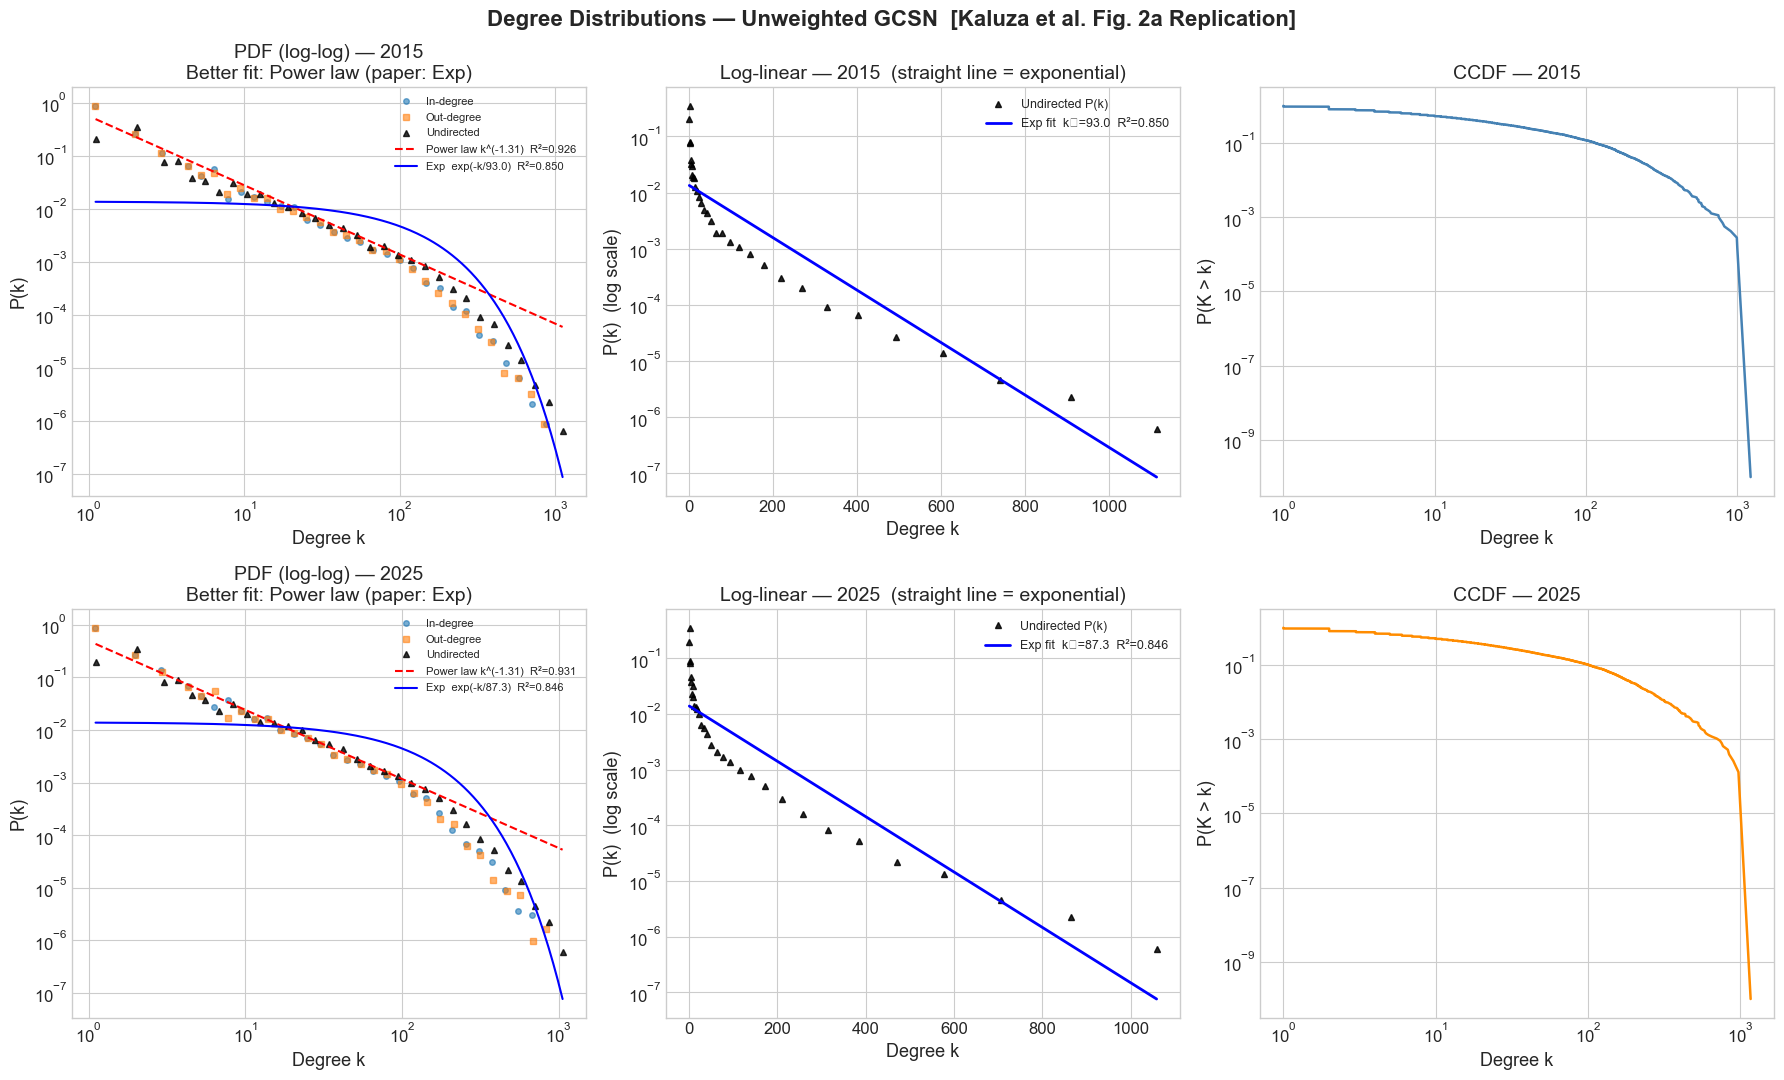


  Degree Distribution — Fit Comparison
  2015: <k>=41.07  max=1,233
         Power-law mu=1.306  R²=0.9262
         Exponential k0=93.0  R²=0.8501  ← higher R² = better
  2025: <k>=36.15  max=1,171
         Power-law mu=1.314  R²=0.9314
         Exponential k0=87.3  R²=0.8463  ← higher R² = better

  Paper (Kaluza 2010): P(k) fitted with exp(-k/k0); power law is poorer fit


In [30]:
# Importing additional libraries for degree distribution analysis and fitting
from scipy import stats as _stats

# Defining the function to perform log-binning of degree data for better visualization of degree distributions, especially for heavy-tailed distributions
def log_binning(data, n_bins=35):

    """Log-spaced histogram with geometric-mean bin centres (density=True)."""

    data = np.asarray(data, dtype=float) # Converting the input data to a NumPy array of type float for processing
    data = data[data > 0] # Filtering out non-positive values from the data, as degree distributions are typically defined for positive integers (degrees)

    if len(data) == 0: # If there are no valid data points after filtering, return empty arrays for both the bin centers and the histogram values
        return np.array([]), np.array([])
    
    # Creating logarithmically spaced bins between the minimum and maximum values of the data, with n_bins number of bins
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins + 1)

    # Calculating the histogram of the data using the defined logarithmic bins, with density=True to get a probability density function (PDF) rather than raw counts
    hist, edges = np.histogram(data, bins=bins, density=True)

    # Calculating the geometric mean of the bin edges to get the bin centers, which is more appropriate for log-binned data than the arithmetic mean
    centres = np.sqrt(edges[:-1] * edges[1:])

    # Filtering out bins that have a count of zero in the histogram, as these do not contribute to the degree distribution and can cause issues in log-log plots
    mask = hist > 0

    # Returning the bin centers and the corresponding histogram values for the bins that have non-zero counts, which can be used for plotting the degree distribution on a log-log scale
    return centres[mask], hist[mask]

# Defining the function to calculate the maximum likelihood estimate (MLE) of the power-law exponent for a given degree distribution, using the formula from Clauset et al. 2009 (Eq. 3.1)
def mle_powerlaw_exponent(data, x_min=1):
    """MLE power-law exponent (Clauset et al. 2009 Eq. 3.1)."""
    data = np.asarray(data, dtype=float) # Converting the input data to a NumPy array of type float for processing
    data = data[data >= x_min] # Filtering the data to include only values that are greater than or equal to x_min, as the power-law fit is typically applied to the tail of the distribution above a certain threshold (x_min)
    n = len(data) # Calculating the number of data points that are greater than or equal to x_min
    if n == 0:
        return np.nan
    return 1.0 + n / np.sum(np.log(data / (x_min - 0.5))) # Calculating the MLE of the power-law exponent using the formula from Clauset et al. 2009

# Defining the function to fit an exponential distribution to the degree distribution data
def fit_exponential(k_vals, pk_vals):

    """Fit P(k) ~ A * exp(-k/k0) via log-linear regression.
    Returns k0, A, R² in log-linear space.
    """

    valid = pk_vals > 0 # Filtering out bins where the probability is zero or negative, as these cannot be used in log-linear regression
    if valid.sum() < 3: # If there are fewer than 3 valid data points, return NaN for all parameters, as a fit cannot be reliably performed
        return np.nan, np.nan, np.nan
    
    # Performing linear regression on the valid data points in log-linear space to fit the exponential distribution, where the slope corresponds to -1/k0 and the intercept corresponds to log(A)
    slope, intercept, r, _, _ = _stats.linregress(k_vals[valid],
                                                    np.log(pk_vals[valid])) 
    
    k0  = -1.0 / slope if slope != 0 else np.nan # Calculating the characteristic degree k0 from the slope of the fitted line, which represents the scale of the exponential decay in the degree distribution
    A   = np.exp(intercept) # Calculating the prefactor A from the intercept of the fitted line, which represents the value of P(k) at k=0 in the exponential fit
    r2  = r ** 2 # Calculating the coefficient of determination (R²) from the correlation coefficient r, which indicates how well the exponential model fits the data in log-linear space

    return k0, A, r2 # Returning the fitted parameters k0, A, and the R² value for the exponential fit

# Defining the function to calculate the R² value for a power-law fit in log-log space
def fit_powerlaw_r2(k_vals, pk_vals):

    """R² for power-law fit in log-log space."""

    valid = (pk_vals > 0) & (k_vals > 0) # Filtering out bins where the probability is zero or negative, and where the degree values are non-positive, as these cannot be used in log-log regression for fitting a power-law distribution
    if valid.sum() < 3: # If there are fewer than 3 valid data points, return NaN for the R² value, as a fit cannot be reliably performed
        return np.nan
    
    # Performing linear regression on the valid data points in log-log space to fit a power-law distribution, where the slope corresponds to the negative of the power-law exponent and the intercept corresponds to the log of the prefactor
    _, _, r, _, _ = _stats.linregress(np.log10(k_vals[valid]),
                                       np.log10(pk_vals[valid]))
    
    return r ** 2 # Returning the R² value for the power-law fit in log-log space, which indicates how well the power-law model fits the data

# Defining the function to compute the complementary cumulative distribution function (CCDF) for a given degree distribution, which is useful for visualizing the tail of the distribution and comparing it to theoretical models
def compute_ccdf(data):

    """Complementary CDF: P(K > k)."""

    # Sorting the degree data and calculating the complementary cumulative distribution function (CCDF), which gives the probability that a randomly chosen node has a degree greater than k
    x = np.sort(data)
    y = 1.0 - np.arange(1, len(x) + 1) / len(x) # Calculating the CCDF values by taking 1 minus the cumulative distribution function (CDF), which is computed as the rank of each data point divided by the total number of data points
    return x, y # Returning the sorted degree values and their corresponding CCDF values

# Creating a figure with 2 rows and 3 columns of subplots to visualize the degree distributions for both years (2015 and 2025) in different ways
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Degree Distributions — Unweighted GCSN  [Kaluza et al. Fig. 2a Replication]',
             fontsize=16, fontweight='bold')

# Initializing a dictionary to store the degree distribution statistics and fit results for both years
deg_stats = {}

# Iterating over both years and their corresponding directed and undirected graphs
for row, (year, Gd, Gu) in enumerate([
    ('2015', Gd_2015, Gu_2015),
    ('2025', Gd_2025, Gu_2025)
]):
    
    # Calculating the in-degree, out-degree, and total degree for the directed and undirected graphs, respectively, and storing them as NumPy arrays for further analysis
    in_deg  = np.array([d for _, d in Gd.in_degree()])
    out_deg = np.array([d for _, d in Gd.out_degree()])
    deg     = np.array([d for _, d in Gu.degree()])

    # Calculating the MLE of the power-law exponent for the undirected degree distribution, using x_min=1 as the minimum degree for fitting
    mu     = mle_powerlaw_exponent(deg, x_min=1)
    k_u, pk_u = log_binning(deg)

    # Fitting the exponential distribution to the undirected degree distribution and calculating the R² value for the fit
    k0, A_exp, r2_exp = fit_exponential(k_u, pk_u)

    # Calculating the R² value for the power-law fit in log-log space for the undirected degree distribution
    r2_pow = fit_powerlaw_r2(k_u, pk_u)

    # Calculating the log-binned degree distributions for the in-degree and out-degree of the directed graph, which will be plotted in the first panel to compare with the undirected degree distribution
    k_in,  pk_in  = log_binning(in_deg)
    k_out, pk_out = log_binning(out_deg)

    # ---- Panel 1: Log-log PDF with power-law and exponential fits ----
    ax = axes[row, 0]
    ax.loglog(k_in,  pk_in,  'o', ms=4, alpha=0.6, label='In-degree')
    ax.loglog(k_out, pk_out, 's', ms=4, alpha=0.6, label='Out-degree')
    ax.loglog(k_u,   pk_u,   '^', ms=5, alpha=0.8, color='k', label='Undirected')

    k_fit = np.logspace(np.log10(max(k_u.min(), 1)), np.log10(k_u.max()), 200)
    # Power-law reference
    anchor = len(k_u) // 2
    if anchor < len(k_u):
        scale_pl = pk_u[anchor] * k_u[anchor] ** mu
        ax.loglog(k_fit, scale_pl * k_fit**(-mu), 'r--', lw=1.5,
                  label=f'Power law k^(-{mu:.2f})  R²={r2_pow:.3f}')
    # Exponential reference (in log-log space it curves)
    if not np.isnan(k0):
        ax.loglog(k_fit, A_exp * np.exp(-k_fit / k0), 'b-', lw=1.5,
                  label=f'Exp  exp(-k/{k0:.1f})  R²={r2_exp:.3f}')

    better = 'Exp' if r2_exp > r2_pow else 'Power law'
    ax.set_xlabel('Degree k')
    ax.set_ylabel('P(k)')
    ax.set_title(f'PDF (log-log) — {year}\nBetter fit: {better} (paper: Exp)')
    ax.legend(fontsize=8)

    # ---- Panel 2: Log-linear (semi-log) — exponential shows as straight line ----
    ax2 = axes[row, 1]
    ax2.semilogy(k_u,   pk_u,   '^k', ms=5, alpha=0.85, label='Undirected P(k)')
    if not np.isnan(k0):
        ax2.semilogy(k_fit, A_exp * np.exp(-k_fit / k0), 'b-', lw=2,
                     label=f'Exp fit  k₀={k0:.1f}  R²={r2_exp:.3f}')
    ax2.set_xlabel('Degree k')
    ax2.set_ylabel('P(k)  (log scale)')
    ax2.set_title(f'Log-linear — {year}  (straight line = exponential)')
    ax2.legend(fontsize=9)

    # ---- Panel 3: CCDF ----
    x_ccdf, y_ccdf = compute_ccdf(deg)
    ax3 = axes[row, 2]
    ax3.loglog(x_ccdf, y_ccdf + 1e-10, '-', lw=1.8, color='steelblue' if year=='2015' else 'darkorange')
    ax3.set_xlabel('Degree k')
    ax3.set_ylabel('P(K > k)')
    ax3.set_title(f'CCDF — {year}')

    deg_stats[year] = {
        'mean_in': float(in_deg.mean()),
        'mean_out': float(out_deg.mean()),
        'mean_undirected': float(deg.mean()),
        'max_degree': int(deg.max()),
        'mu': float(mu),
        'k0_exp': float(k0) if not np.isnan(k0) else None,
        'r2_exp': float(r2_exp),
        'r2_pow': float(r2_pow),
        'in_deg': in_deg, 'out_deg': out_deg, 'deg': deg
    }

# Adjusting the layout of the figure to prevent overlap and ensure that all subplots and titles are clearly visible, and then saving the figure to the specified directory with a high resolution (150 dpi) and tight bounding box to minimize whitespace around the figure
plt.tight_layout()
plt.savefig(FIG_DIR + '01_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing a summary of the degree distribution statistics and fit results for both years
print(f'\n{"="*72}')
print(f'  Degree Distribution — Fit Comparison')
print(f'{"="*72}')
for yr in ['2015', '2025']:
    d = deg_stats[yr]
    print(f'  {yr}: <k>={d["mean_undirected"]:.2f}  max={d["max_degree"]:,}')
    print(f'         Power-law mu={d["mu"]:.3f}  R²={d["r2_pow"]:.4f}')
    print(f'         Exponential k0={d["k0_exp"]:.1f}  R²={d["r2_exp"]:.4f}  '
          f'← higher R² = better')
print(f'\n  Paper (Kaluza 2010): P(k) fitted with exp(-k/k0); power law is poorer fit')


## 4. Clustering Coefficient

Kaluza et al. report C = 0.49 for the full 2007 GCSN.  
We also plot C(k) vs k to check whether well-connected ports have lower clustering (hierarchical structure).


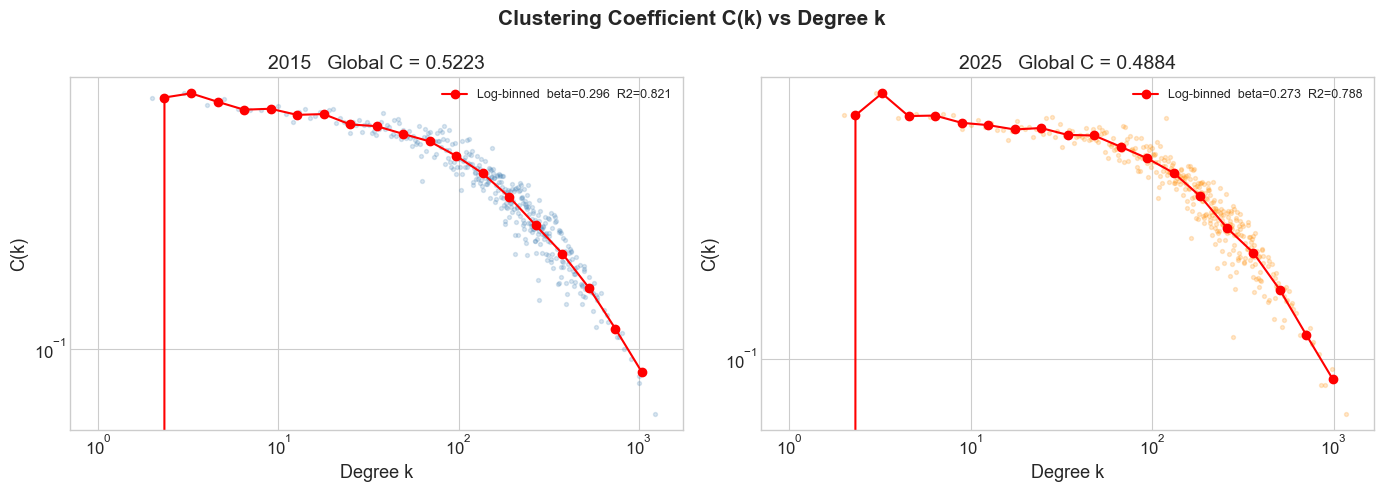


Metric                                     2015     2025  Paper07
Clustering coefficient C                 0.5223   0.4884     0.49
C(k) decay exponent beta                  0.296    0.273        —
C(k) fit R^2                              0.821    0.788        —


In [31]:
# Defining the function to perform clustering analysis on the given undirected graph
def clustering_analysis(Gu, year):

    """Global clustering coefficient and C(k) profile."""

    # Calculating the global clustering coefficient for the undirected graph, which gives an overall measure of the tendency of nodes to cluster together in the network
    C_global = nx.average_clustering(Gu)

    # Calculating the local clustering coefficient for each node in the undirected graph, which measures the degree to which nodes in a graph tend to cluster together
    clust = nx.clustering(Gu)

    # Calculating the degree of each node in the undirected graph, which will be used to analyze how the clustering coefficient varies with degree (C(k))
    deg   = dict(Gu.degree())

    # Grouping the clustering coefficients by degree to compute the average clustering coefficient for nodes of each degree k
    ck_map = defaultdict(list)
    for node in Gu.nodes():
        k = deg[node]
        if k > 0:
            ck_map[k].append(clust[node])

    # Calculating the average clustering coefficient C(k) for each degree k by taking the mean of the clustering coefficients for all nodes that have degree k
    k_all = np.array(sorted(ck_map.keys()))
    c_all = np.array([np.mean(ck_map[k]) for k in k_all])

    # Performing log-binning of the C(k) data to reduce noise and better visualize the relationship between clustering coefficient and degree, especially for higher degrees where data may be sparse
    if len(k_all) > 2:
        bins = np.logspace(np.log10(max(k_all.min(), 1)),
                           np.log10(k_all.max()), 22)
        k_bin, c_bin = [], []
        for i in range(len(bins) - 1):
            mask = (k_all >= bins[i]) & (k_all < bins[i + 1])
            if mask.sum() > 0:
                k_bin.append(np.sqrt(bins[i] * bins[i + 1]))
                c_bin.append(np.mean(c_all[mask]))
        k_bin = np.array(k_bin)
        c_bin = np.array(c_bin)
    else:
        k_bin, c_bin = k_all, c_all

    # Fitting a power-law decay to the log-binned C(k) data to estimate the exponent beta, which characterizes how the clustering coefficient decreases with degree, and calculating the R² value for the fit to assess how well the power-law model describes the relationship between C(k) and k
    valid = (k_bin > 0) & (c_bin > 0)
    if valid.sum() >= 3:
        slope, intercept, r, p, _ = stats.linregress(
            np.log10(k_bin[valid]), np.log10(c_bin[valid]))
        beta = -slope
        r2   = r ** 2
    else:
        beta, r2 = np.nan, np.nan

    # Returning a dictionary containing the above calculated metrics and data for further analysis and plotting
    return {
        'C': C_global,
        'beta': beta,
        'r2': r2,
        'k_all': k_all, 'c_all': c_all,
        'k_bin': k_bin, 'c_bin': c_bin,
    }

# Performing clustering analysis for both the 2015 and 2025 undirected graphs
res_c_2015 = clustering_analysis(Gu_2015, '2015')
res_c_2025 = clustering_analysis(Gu_2025, '2025')

# Creating a figure with 1 row and 2 columns of subplots to visualize the relationship between the clustering coefficient C(k) and degree k for both years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clustering Coefficient C(k) vs Degree k', fontsize=15, fontweight='bold')

# Iterating over both years and their corresponding clustering analysis results
for ax, res, year, color in [
    (axes[0], res_c_2015, '2015', 'steelblue'),
    (axes[1], res_c_2025, '2025', 'darkorange')
]:

    # Plotting the raw C(k) data as a scatter plot to visualize the relationship between clustering coefficient and degree for all nodes in the network, with some transparency (alpha) to better see the density of points
    ax.scatter(res['k_all'], res['c_all'], alpha=0.2, s=8, color=color)
    if len(res['k_bin']) > 0:
        ax.loglog(res['k_bin'], res['c_bin'], 'o-', color='red', ms=6, lw=1.5,
                  label=f'Log-binned  beta={res["beta"]:.3f}  R2={res["r2"]:.3f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('C(k)')
    ax.set_title(f'{year}   Global C = {res["C"]:.4f}')
    ax.legend(fontsize=9)

# Adjusting the layout of the figure to prevent overlap and ensure that all subplots and titles are clearly visible, and then saving the figure to the specified directory
plt.tight_layout()
plt.savefig(FIG_DIR + '01_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing a summary of the clustering analysis results for both years
print(f'\n{"="*60}')
print(f'{"Metric":<38} {"2015":>8} {"2025":>8} {"Paper07":>8}')
print(f'{"="*60}')
print(f'{"Clustering coefficient C":<38} {res_c_2015["C"]:>8.4f} {res_c_2025["C"]:>8.4f} {PAPER_2007["clustering"]:>8.2f}')
print(f'{"C(k) decay exponent beta":<38} {res_c_2015["beta"]:>8.3f} {res_c_2025["beta"]:>8.3f} {"—":>8}')
print(f'{"C(k) fit R^2":<38} {res_c_2015["r2"]:>8.3f} {res_c_2025["r2"]:>8.3f} {"—":>8}')


## 5. Characteristic Path Length L

Kaluza et al. report L = 2.50 for the 2007 GCSN, demonstrating **small-world** properties.

With N ≈ 7 000 nodes the exact O(N²) BFS is slow (~30 min). We use **random sampling** of 400 source nodes from the Giant Connected Component (GCC) to obtain a reliable estimate in seconds.


Extracting Giant Connected Components...
2015 GCC: 7,081 nodes, 145,736 edges
2025 GCC: 7,688 nodes, 139,452 edges

Computing sampled path lengths (n_samples=400, ~1-3 min)...
  2015 done: L = 3.2588
  2025 done: L = 3.5650


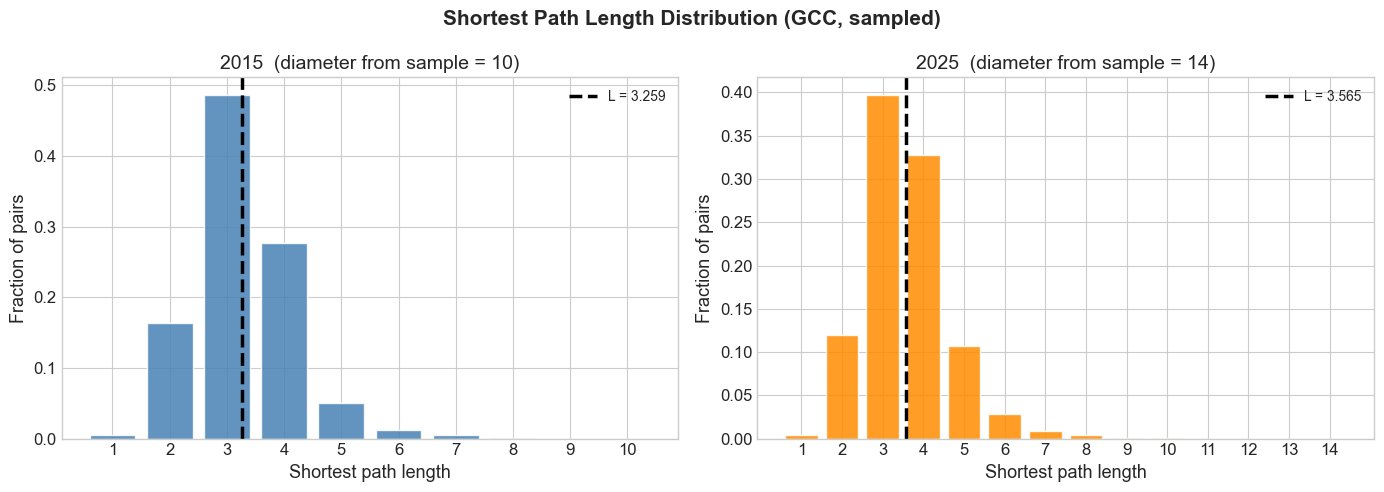


Metric                                     2015     2025  Paper07
Avg path length L (sampled, GCC)         3.2588   3.5650     2.50
Diameter (from sample)                       10       14        —


In [32]:
# Defining the function to approximate the average shortest path length in the graph by performing breadth-first search (BFS) from a random sample of source nodes
def sample_avg_path_length(G, n_samples=400, seed=42):

    """
    Approximate average shortest path length by BFS from a random sample
    of source nodes. Returns (apl_estimate, all_sampled_distances_array).
    """

    # Setting up a random number generator with a specified seed for reproducibility, and selecting a random sample of nodes from the graph to serve as source nodes for the BFS
    rng = np.random.default_rng(seed)
    nodes = np.array(list(G.nodes()))
    sample = rng.choice(nodes, size=min(n_samples, len(nodes)), replace=False)

    # Performing BFS from each source node in the sample to calculate the shortest path lengths to all reachable nodes, and collecting these distances in a list while filtering out zero distances (which correspond to the source node itself)
    all_dists = []
    for s in sample:
        lengths = nx.single_source_shortest_path_length(G, s)
        all_dists.extend(v for v in lengths.values() if v > 0)

    # Converting the list of sampled distances to a NumPy array for efficient computation, and calculating the mean of these distances to get an estimate of the average shortest path length in the graph
    arr = np.array(all_dists, dtype=int)
    return float(arr.mean()), arr

# Extracting the giant connected components (GCC) from both the 2015 and 2025 undirected graphs to ensure that the average path length is computed on the largest connected portion of the network, which is necessary for meaningful path length analysis
print('Extracting Giant Connected Components...')
gcc_2015 = Gu_2015.subgraph(
    max(nx.connected_components(Gu_2015), key=len)).copy()
gcc_2025 = Gu_2025.subgraph(
    max(nx.connected_components(Gu_2025), key=len)).copy()

# Printing the number of nodes and edges in the giant connected components for both years to provide context for the subsequent path length analysis
print(f'2015 GCC: {gcc_2015.number_of_nodes():,} nodes, {gcc_2015.number_of_edges():,} edges')
print(f'2025 GCC: {gcc_2025.number_of_nodes():,} nodes, {gcc_2025.number_of_edges():,} edges')

# Computing the average path length and the distribution of sampled shortest path lengths for both years using the previously defined function, and printing the results to compare with the baseline from Kaluza et al. 2010
print('\nComputing sampled path lengths (n_samples=400, ~1-3 min)...')
apl_2015, dists_2015 = sample_avg_path_length(gcc_2015, n_samples=400)
print(f'  2015 done: L = {apl_2015:.4f}')

apl_2025, dists_2025 = sample_avg_path_length(gcc_2025, n_samples=400)
print(f'  2025 done: L = {apl_2025:.4f}')

# Calculating the diameter of the giant connected component for both years based on the maximum sampled shortest path length
diam_2015 = int(dists_2015.max())
diam_2025 = int(dists_2025.max())

# Creating a figure with 1 row and 2 columns of subplots to visualize the distribution of shortest path lengths for both years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shortest Path Length Distribution (GCC, sampled)', fontsize=15, fontweight='bold')

# Iterating over both years and their corresponding sampled shortest path length distributions
for ax, dists, apl, year, color in [
    (axes[0], dists_2015, apl_2015, '2015', 'steelblue'),
    (axes[1], dists_2025, apl_2025, '2025', 'darkorange')
]:

    # Calculating the unique shortest path lengths and their corresponding counts from the sampled distances, and plotting a bar chart of the fraction of pairs that have each shortest path length, with a vertical dashed line indicating the estimated average path length (APL) from the sample
    vals, counts = np.unique(dists, return_counts=True)
    ax.bar(vals, counts / counts.sum(), color=color, edgecolor='white', alpha=0.85)
    ax.axvline(apl, color='black', linestyle='--', lw=2.5, label=f'L = {apl:.3f}')
    ax.set_xlabel('Shortest path length')
    ax.set_ylabel('Fraction of pairs')
    ax.set_title(f'{year}  (diameter from sample = {dists.max()})')
    ax.set_xticks(vals)
    ax.legend()

# Adjusting the layout of the figure to prevent overlap and ensure that all subplots and titles are clearly visible, and then saving the figure to the specified directory
plt.tight_layout()
plt.savefig(FIG_DIR + '01_path_length.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing a summary of the average path length and diameter metrics for both years, and comparing them to the baseline from Kaluza et al. 2010
print(f'\n{"="*60}')
print(f'{"Metric":<38} {"2015":>8} {"2025":>8} {"Paper07":>8}')
print(f'{"="*60}')
print(f'{"Avg path length L (sampled, GCC)":<38} {apl_2015:>8.4f} {apl_2025:>8.4f} {PAPER_2007["path_length"]:>8.2f}')
print(f'{"Diameter (from sample)":<38} {diam_2015:>8,} {diam_2025:>8,} {"—":>8}')


## 6. Small-World Properties

A **small-world network** has:
- Much higher clustering than a random (Erdos-Renyi) graph of the same size and density: γ = C_real / C_rand >> 1
- Similar path length to a random graph: λ = L_real / L_rand ≈ 1
- Small-world coefficient σ = γ / λ >> 1 (Humphries & Gurney 2008)

For ER: C_rand ≈ <k>/N, L_rand ≈ ln(N) / ln(<k>)


In [33]:
# Defining the function to calculate the small-world metrics (gamma, lambda, sigma) for the given undirected graph
def small_world_metrics(Gu, apl, C, label=''):

    # Calculating the number of nodes and the average degree of the undirected graph
    N  = Gu.number_of_nodes()
    k  = np.mean([d for _, d in Gu.degree()])

    # Calculating the expected clustering coefficient and average path length for a random Erdős–Rényi (ER) graph with the same number of nodes and average degree
    C_rand = k / N                                          # ER approximation
    L_rand = np.log(N) / np.log(k) if k > 1 else np.inf   # ER approximation

    # Calculating the small-world metrics
    gamma = C / C_rand   if C_rand > 0 else np.inf
    lam   = apl / L_rand if L_rand > 0 else np.inf
    sigma = gamma / lam  if lam    > 0 else np.inf

    # Printing the small-world analysis results for the given graph
    print(f'\n=== Small-World Analysis: {label} ===')
    print(f'  N = {N:,},  <k> = {k:.2f}')
    print(f'  C_real  = {C:.4f}')
    print(f'  C_rand  = {C_rand:.6f}  (ER)')
    print(f'  L_real  = {apl:.4f}  (sampled)')
    print(f'  L_rand  = {L_rand:.4f}  (ER)')
    print(f'  gamma   = C_real / C_rand = {gamma:.1f}  (clustering enrichment)')
    print(f'  lambda  = L_real / L_rand = {lam:.4f}  (path length ratio)')
    print(f'  sigma   = gamma / lambda  = {sigma:.1f}  (sigma >> 1 -> small-world)')

    return {'C_rand': C_rand, 'L_rand': L_rand,
            'gamma': gamma, 'lam': lam, 'sigma': sigma}

# Calculating the small-world metrics for both the 2015 and 2025 undirected graphs using the previously computed average path lengths and clustering coefficients, and printing the results to assess whether the GCSN exhibits small-world properties in both years
sw_2015 = small_world_metrics(Gu_2015, apl_2015, res_c_2015['C'], '2015')
sw_2025 = small_world_metrics(Gu_2025, apl_2025, res_c_2025['C'], '2025')



=== Small-World Analysis: 2015 ===
  N = 7,097,  <k> = 41.07
  C_real  = 0.5223
  C_rand  = 0.005787  (ER)
  L_real  = 3.2588  (sampled)
  L_rand  = 2.3867  (ER)
  gamma   = C_real / C_rand = 90.2  (clustering enrichment)
  lambda  = L_real / L_rand = 1.3654  (path length ratio)
  sigma   = gamma / lambda  = 66.1  (sigma >> 1 -> small-world)

=== Small-World Analysis: 2025 ===
  N = 7,717,  <k> = 36.15
  C_real  = 0.4884
  C_rand  = 0.004685  (ER)
  L_real  = 3.5650  (sampled)
  L_rand  = 2.4949  (ER)
  gamma   = C_real / C_rand = 104.2  (clustering enrichment)
  lambda  = L_real / L_rand = 1.4289  (path length ratio)
  sigma   = gamma / lambda  = 73.0  (sigma >> 1 -> small-world)


## 7. Degree-Degree Correlations

We measure:
- **Assortativity r** (Newman 2002): r < 0 → disassortative (hubs connect to low-degree nodes)
- **KNN k_nn(k)**: average degree of neighbors of degree-k nodes.  
  k_nn(k) ~ k^ν; ν < 0 confirms disassortativity.


Computing assortativity and KNN...
  2015: assortativity r = -0.0694,  KNN slope nu = -0.0145
  2025: assortativity r = -0.0080,  KNN slope nu = 0.0553


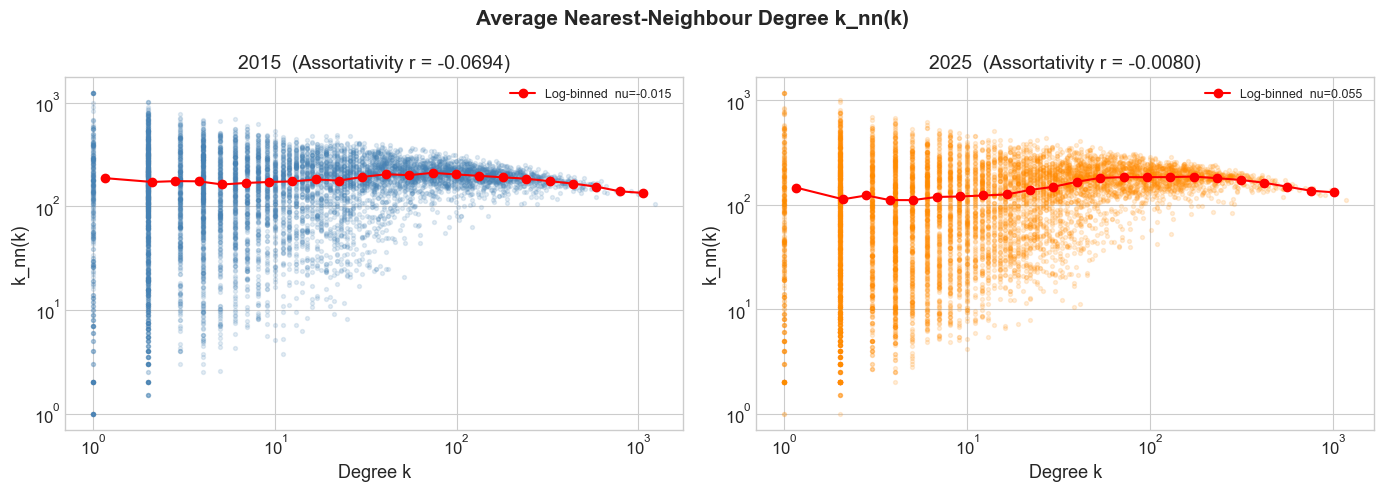


Note: r < 0 indicates disassortativity (hubs connect to low-degree nodes).
      nu < 0 in KNN plot confirms the same disassortative mixing.


In [34]:
# Defining the function to perform degree correlation analysis
def degree_correlation_analysis(Gu, label=''):

    # Calculating the degree assortativity coefficient for the undirected graph, which measures the tendency of nodes to connect to other nodes with similar degree (r > 0) or dissimilar degree (r < 0)
    r = nx.degree_assortativity_coefficient(Gu)

    # Calculating the average nearest neighbor degree (k_nn) for each node in the undirected graph,
    knn  = nx.average_neighbor_degree(Gu)
    deg  = dict(Gu.degree()) # Calculating the degree of each node in the undirected graph

    # Extracting the degree and average nearest neighbor degree for all nodes in the graph
    k_all   = np.array([deg[n] for n in Gu.nodes()])
    knn_all = np.array([knn[n] for n in Gu.nodes()])

    # Performing log-binning of the k_nn(k) data to reduce noise and better visualize the relationship between average nearest neighbor degree and degree, especially for higher degrees where data may be sparse
    if k_all.max() > k_all.min() and k_all.min() > 0:
        bins = np.logspace(np.log10(k_all.min()), np.log10(k_all.max()), 25)
        k_bin, knn_bin = [], []
        for i in range(len(bins) - 1):
            mask = (k_all >= bins[i]) & (k_all < bins[i + 1])
            if mask.sum() > 0:
                k_bin.append(np.sqrt(bins[i] * bins[i + 1]))
                knn_bin.append(np.mean(knn_all[mask]))
        k_bin   = np.array(k_bin)
        knn_bin = np.array(knn_bin)
    else:
        k_bin, knn_bin = k_all, knn_all

    # Fitting a power-law decay to the log-binned k_nn(k) data to estimate the exponent nu, which characterizes how the average nearest neighbor degree changes with degree
    # Calculating the R² value for the fit to assess how well the power-law model describes the relationship between k_nn and k
    valid = (k_bin > 0) & (knn_bin > 0)
    if valid.sum() >= 3:
        nu, _, r2, _, _ = stats.linregress(
            np.log10(k_bin[valid]), np.log10(knn_bin[valid]))
    else:
        nu, r2 = np.nan, np.nan

    # Printing the degree correlation analysis results for the given graph
    print(f'  {label}: assortativity r = {r:.4f},  KNN slope nu = {nu:.4f}')

    return {
        'r': r, 'nu': nu,
        'k_all': k_all, 'knn_all': knn_all,
        'k_bin': k_bin, 'knn_bin': knn_bin
    }

# Performing degree correlation analysis for both the 2015 and 2025 undirected graphs
print('Computing assortativity and KNN...')
dc_2015 = degree_correlation_analysis(Gu_2015, '2015')
dc_2025 = degree_correlation_analysis(Gu_2025, '2025')

# Creating a figure with 1 row and 2 columns of subplots to visualize the relationship between average nearest neighbor degree k_nn(k) and degree k for both years
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Average Nearest-Neighbour Degree k_nn(k)', fontsize=15, fontweight='bold')

# Iterating over both years and their corresponding degree correlation analysis results
for ax, dc, year, color in [
    (axes[0], dc_2015, '2015', 'steelblue'),
    (axes[1], dc_2025, '2025', 'darkorange')
]:

    # Plotting the raw k_nn(k) data as a scatter plot to visualize the relationship between average nearest neighbor degree and degree for all nodes in the network, with some transparency (alpha) to better see the density of points
    ax.scatter(dc['k_all'], dc['knn_all'], alpha=0.15, s=8, color=color)
    if len(dc['k_bin']) > 0:
        ax.loglog(dc['k_bin'], dc['knn_bin'], 'o-', color='red', ms=6, lw=1.5,
                  label=f'Log-binned  nu={dc["nu"]:.3f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('k_nn(k)')
    ax.set_title(f'{year}  (Assortativity r = {dc["r"]:.4f})')
    ax.legend(fontsize=9)

# Adjusting the layout of the figure to prevent overlap and ensure that all subplots and titles are clearly visible, and then saving the figure to the specified directory
plt.tight_layout()
plt.savefig(FIG_DIR + '01_knn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNote: r < 0 indicates disassortativity (hubs connect to low-degree nodes).')
print(f'      nu < 0 in KNN plot confirms the same disassortative mixing.')


## 8. Rich-Club Coefficient

phi(k) = fraction of edges between nodes with degree > k out of all possible edges among such nodes.  
Rising phi(k) → rich-club phenomenon (hubs are densely interconnected).


Computing rich-club coefficients...


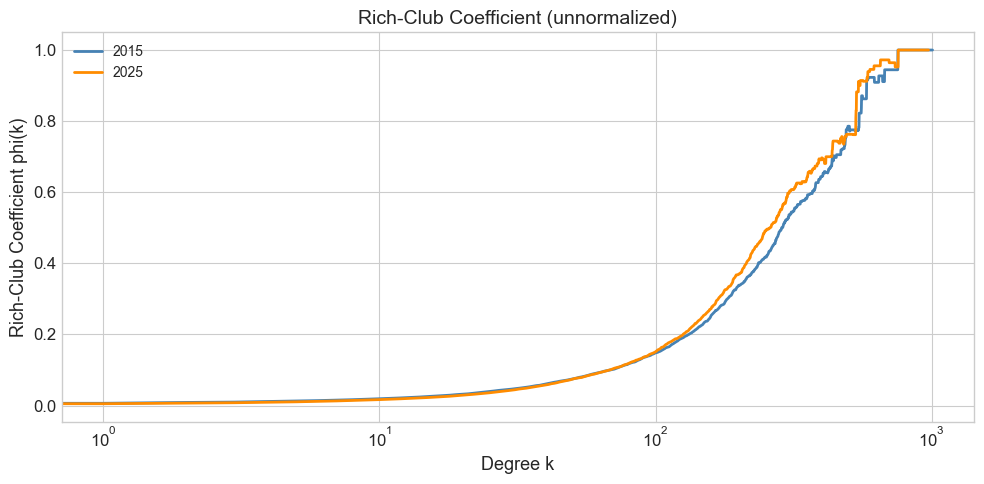

Rising phi(k) indicates that high-degree ports (hubs) are more densely
interconnected than expected — consistent with the paper's findings.


In [35]:
# Calculating the rich-club coefficients for both the 2015 and 2025 undirected graphs using NetworkX's built-in function, which measures the tendency of high-degree nodes (hubs) to be more densely interconnected than expected by chance
print('Computing rich-club coefficients...')
rc_2015 = nx.rich_club_coefficient(Gu_2015, normalized=False)
rc_2025 = nx.rich_club_coefficient(Gu_2025, normalized=False)

# Extracting the degree values (k) and their corresponding rich-club coefficients (phi(k)) for the 2015 graph, and converting them to NumPy arrays for plotting
k_rc_2015  = np.array(sorted(rc_2015.keys()))
phi_rc_2015 = np.array([rc_2015[k] for k in k_rc_2015])

# Extracting the degree values (k) and their corresponding rich-club coefficients (phi(k)) for the 2025 graph, and converting them to NumPy arrays for plotting
k_rc_2025  = np.array(sorted(rc_2025.keys()))
phi_rc_2025 = np.array([rc_2025[k] for k in k_rc_2025])

# Creating a figure to plot the rich-club coefficient phi(k) as a function of degree k for both years, using a logarithmic scale for the x-axis to better visualize the behavior of phi(k) across different degree values, and saving the figure to the specified directory
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_rc_2015, phi_rc_2015, '-', lw=2, label='2015', color='steelblue')
ax.plot(k_rc_2025, phi_rc_2025, '-', lw=2, label='2025', color='darkorange')
ax.set_xscale('log')
ax.set_xlabel('Degree k')
ax.set_ylabel('Rich-Club Coefficient phi(k)')
ax.set_title('Rich-Club Coefficient (unnormalized)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR + '01_rich_club.png', dpi=150, bbox_inches='tight')
plt.show()

print('Rising phi(k) indicates that high-degree ports (hubs) are more densely')
print('interconnected than expected — consistent with the paper\'s findings.')


## 9. Top Ports by Degree (Betweenness Centrality)



Top 20 ports by degree — 2015
                   port  undirected_degree  in_degree  out_degree
           chn-shanghai               1233        954         932
            bel-antwerp               1007        737         748
nld-rotterdammaasvlakte                999        708         711
          mys-pengerang                910        625         650
          sgp-singapore                827        542         621
           chn-hongkong                804        610         556
             chn-ningbo                779        635         534
          gib-gibraltar                760        560         545
             dnk-skagen                754        517         542
          chn-guangzhou                675        519         467
        mys-pasirgudang                664        444         501
           jpn-yokohama                643        523         463
          nld-rotterdam                620        481         330
         chn-caofeidian                615   

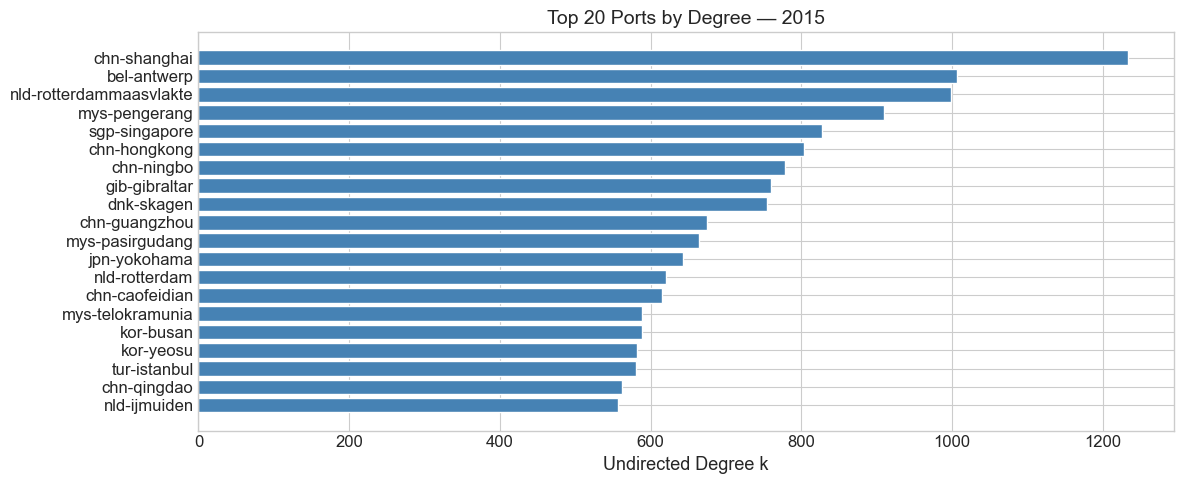


Top 20 ports by degree — 2025
                   port  undirected_degree  in_degree  out_degree
           chn-shanghai               1171        899         921
       mys-telokramunia                974        567         765
            bel-antwerp                901        675         636
nld-rotterdammaasvlakte                846        626         579
             chn-ningbo                829        664         572
          sgp-singapore                771        413         552
          chn-guangzhou                756        568         543
           chn-hongkong                737        552         516
          gib-gibraltar                701        490         528
             dnk-skagen                652        437         483
           chn-shenzhen                618        431         473
          esp-laspalmas                597        402         451
              kor-yeosu                587        430         437
           chn-zhoushan                583   

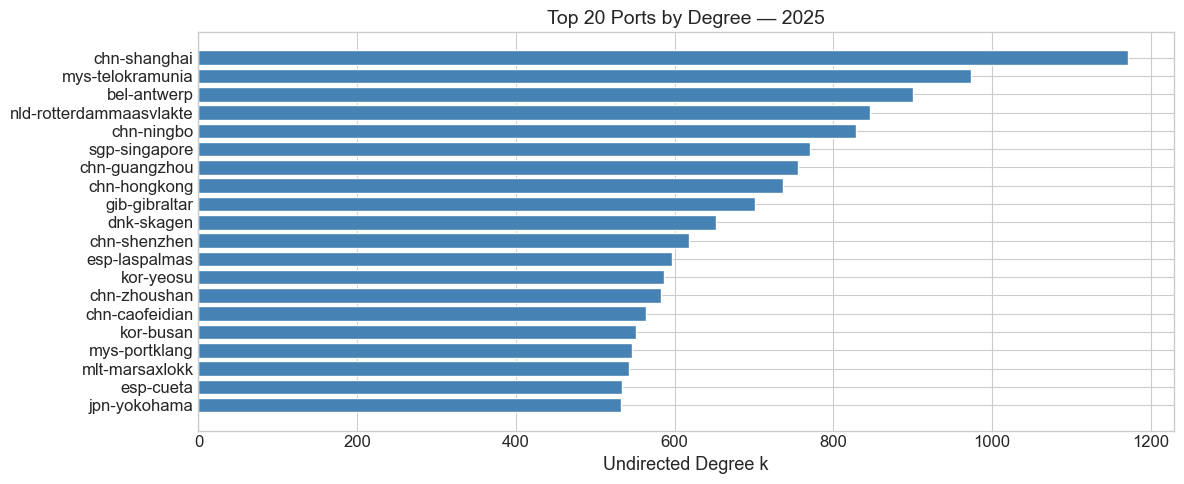

In [36]:
# Defining the number of top ports to be displayed
TOP_N = 20

# Defining the function to create a table of the top ports by degree
def top_ports_table(Gd, Gu, year, top_n=TOP_N):

    # Calculating the out-degree, in-degree, and total degree for the directed and undirected graphs, respectively, and storing them in dictionaries for easy lookup
    out_deg = dict(Gd.out_degree())
    in_deg  = dict(Gd.in_degree())
    u_deg   = dict(Gu.degree())

    # Sorting the ports by their undirected degree in descending order and selecting the top N ports to be included in the table
    top = sorted(u_deg.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Creating a list of dictionaries to store the port name, undirected degree, in-degree, and out-degree for each of the top ports
    rows = []
    for port, k in top:
        rows.append({
            'port': port,
            'undirected_degree': k,
            'in_degree': in_deg.get(port, 0),
            'out_degree': out_deg.get(port, 0),
        })

    # Creating a DataFrame from the list of dictionaries to display the top ports in a tabular format, and printing the table to the console
    df_top = pd.DataFrame(rows)
    print(f'\nTop {top_n} ports by degree — {year}')
    print(df_top.to_string(index=False))

    # Creating a horizontal bar chart to visualize the undirected degree of the top ports, with the port names on the y-axis and the degree values on the x-axis, and saving the figure to the specified directory
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(df_top['port'][::-1], df_top['undirected_degree'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Undirected Degree k')
    ax.set_title(f'Top {top_n} Ports by Degree — {year}')
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'01_top_ports_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return df_top

# Creating tables and bar charts for the top ports by degree for both the 2015 and 2025 graphs using the previously defined function
top_2015 = top_ports_table(Gd_2015, Gu_2015, '2015')
top_2025 = top_ports_table(Gd_2025, Gu_2025, '2025')


## 10. Betweenness Centrality

The paper identifies important **intermediate ports** (high betweenness centrality — BC).
BC counts how often a port lies on the shortest path between every pair of ports.

$$BC(v) = \sum_{s \neq v \neq t} \frac{\sigma(s,t \mid v)}{\sigma(s,t)}$$

For large graphs we use the **random-source approximation** (Brandes & Pich 2007): exact BFS from k random seeds, O(k · N · E).

We compare the BC ranking to the degree ranking to see whether the most connected ports are also the most "transit-critical" ones.

Computing approximate betweenness centrality (k=500 sources each) …
This takes ~2–5 minutes per network.

Top 25 ports by betweenness centrality — 2015
 Rank (BC)                    Port  BC (norm)  Degree k  In-deg  Out-deg
         1            chn-shanghai   0.075194      1233     954      932
         2 nld-rotterdammaasvlakte   0.071908       999     708      711
         3             bel-antwerp   0.055607      1007     737      748
         4           mys-pengerang   0.040951       910     625      650
         5           nld-rotterdam   0.040209       620     481      330
         6              dnk-skagen   0.024199       754     517      542
         7           chn-guangzhou   0.021372       675     519      467
         8            chn-hongkong   0.021241       804     610      556
         9           sgp-singapore   0.020957       827     542      621
        10           gib-gibraltar   0.020829       760     560      545
        11              chn-ningbo   0.020388

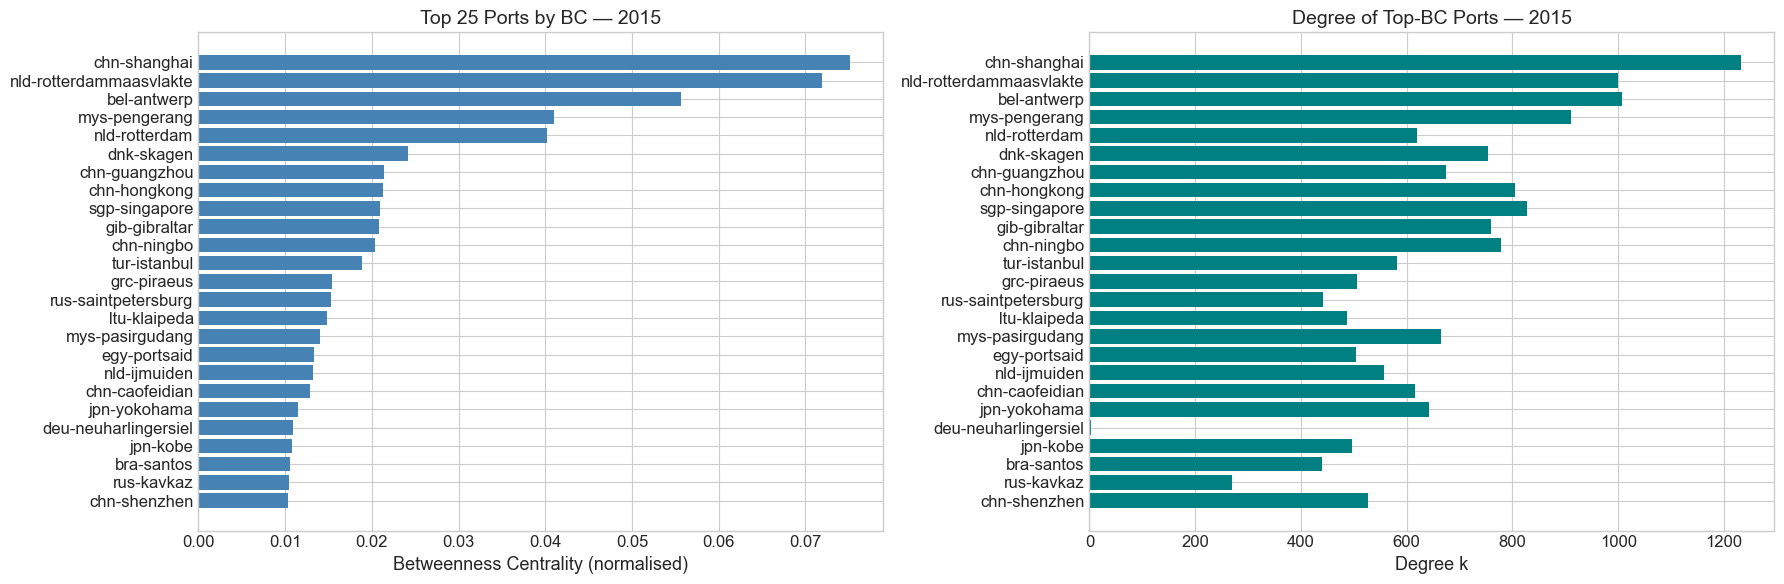


Top 25 ports by betweenness centrality — 2025
 Rank (BC)                    Port  BC (norm)  Degree k  In-deg  Out-deg
         1 nld-rotterdammaasvlakte   0.078060       846     626      579
         2            chn-shanghai   0.076830      1171     899      921
         3             bel-antwerp   0.063133       901     675      636
         4        mys-telokramunia   0.042770       974     567      765
         5              dnk-skagen   0.031657       652     437      483
         6              chn-ningbo   0.027652       829     664      572
         7           chn-guangzhou   0.025870       756     568      543
         8           nld-rotterdam   0.025743       520     442      228
         9     rus-saintpetersburg   0.025619       365     252      237
        10           gib-gibraltar   0.025419       701     490      528
        11           sgp-singapore   0.023690       771     413      552
        12             grc-piraeus   0.019462       414     315      300
    

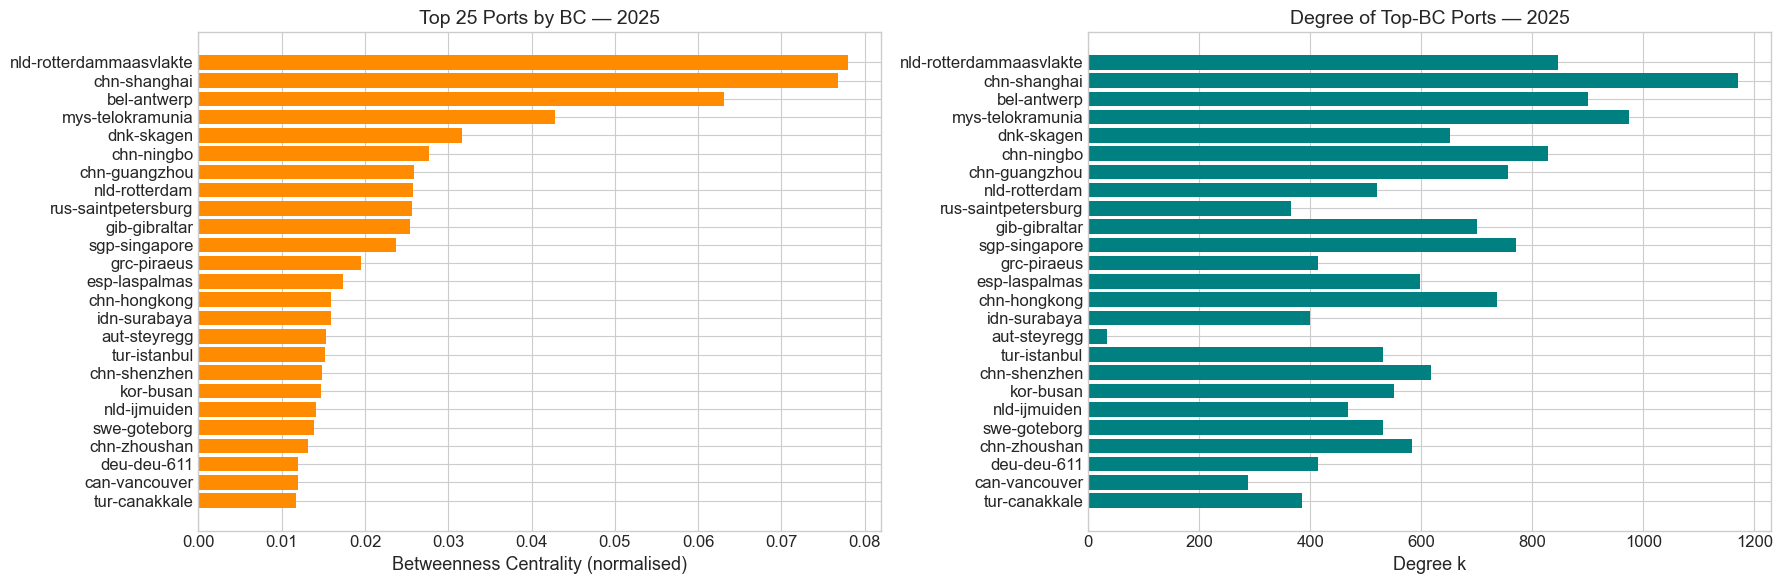


2015  BC vs Degree correlation:
  Kendall tau = 0.6702  (p=0.00e+00)
  Spearman rho = 0.8283  (p=0.00e+00)
  → strong correlation: BC ≈ degree (hubs ARE transit hubs)

2025  BC vs Degree correlation:
  Kendall tau = 0.6140  (p=0.00e+00)
  Spearman rho = 0.7777  (p=0.00e+00)
  → strong correlation: BC ≈ degree (hubs ARE transit hubs)

BC scores saved → ../Figures/01_betweenness_centrality.csv


In [37]:
# Calculating the betweenness centrality for both the 2015 and 2025 undirected graphs using an approximation method that samples from 500 source nodes to estimate the centrality values, which is necessary for larger graphs to reduce computation time
print('Computing approximate betweenness centrality (k=500 sources each) …')
print('This takes ~2–5 minutes per network.')

# Using NetworkX's betweenness_centrality function with the 'k' parameter to specify the number of source nodes to sample for the approximation, and setting 'normalized=True' to get the centrality values normalized by the number of possible pairs of nodes, and using a fixed random seed for reproducibility
bc_2015 = nx.betweenness_centrality(Gu_2015, k=500, normalized=True, seed=42)
bc_2025 = nx.betweenness_centrality(Gu_2025, k=500, normalized=True, seed=42)

# Defining the number of top ports to be displayed in the betweenness centrality table
TOP_BC = 25

# Defining the function to create a table of the top ports by betweenness centrality, along with their degree, in-degree, and out-degree, and to visualize the results with bar charts
def bc_table(Gu, Gd, bc_dict, year, top_n=TOP_BC):

    """Build and print a ranked table: BC, degree, in-deg, out-deg."""

    # Calculating the degree, in-degree, and out-degree for each node in the undirected and directed graphs, respectively, and storing them in dictionaries for easy lookup
    u_deg   = dict(Gu.degree())
    in_deg  = dict(Gd.in_degree())
    out_deg = dict(Gd.out_degree())

    # Sorting the ports by their betweenness centrality values in descending order and selecting the top N ports to be included in the table
    top = sorted(bc_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Creating a list of dictionaries to store the rank, port name, normalized betweenness centrality, undirected degree, in-degree, and out-degree for each of the top ports
    rows = []
    for rank, (port, bc) in enumerate(top, 1):
        rows.append({
            'Rank (BC)': rank,
            'Port': port,
            'BC (norm)': round(bc, 6),
            'Degree k': u_deg.get(port, 0),
            'In-deg': in_deg.get(port, 0),
            'Out-deg': out_deg.get(port, 0),
        })

    # Creating a DataFrame from the list of dictionaries to display the top ports by betweenness centrality in a tabular format, and printing the table to the console
    df_bc = pd.DataFrame(rows)
    print(f'\nTop {top_n} ports by betweenness centrality — {year}')
    print(df_bc.to_string(index=False))

    # Creating a figure with 1 row and 2 columns of subplots to visualize the betweenness centrality and degree of the top ports, with horizontal bar charts for both metrics, and saving the figure to the specified directory
    fig, axes2 = plt.subplots(1, 2, figsize=(18, 6))

    axes2[0].barh(df_bc['Port'][::-1], df_bc['BC (norm)'][::-1],
                  color='steelblue' if year == '2015' else 'darkorange', edgecolor='none')
    axes2[0].set_xlabel('Betweenness Centrality (normalised)')
    axes2[0].set_title(f'Top {top_n} Ports by BC — {year}')

    axes2[1].barh(df_bc['Port'][::-1], df_bc['Degree k'][::-1],
                  color='teal', edgecolor='none')
    axes2[1].set_xlabel('Degree k')
    axes2[1].set_title(f'Degree of Top-BC Ports — {year}')

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'01_betweenness_centrality_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df_bc

# Building and printing the tables of the top ports by betweenness centrality for both the 2015 and 2025 graphs using the previously defined function
df_bc_2015 = bc_table(Gu_2015, Gd_2015, bc_2015, '2015')
df_bc_2025 = bc_table(Gu_2025, Gd_2025, bc_2025, '2025')

# Importing the Kendall tau and Spearman rho correlation functions from the scipy.stats module to analyze the correlation between betweenness centrality and degree for the nodes in the undirected graphs
from scipy.stats import kendalltau, spearmanr

# Iterating over both years and their corresponding betweenness centrality dictionaries and undirected graphs
for year, bc_d, Gu in [('2015', bc_2015, Gu_2015), ('2025', bc_2025, Gu_2025)]:

    # Extracting the list of nodes from the undirected graph, and creating vectors of betweenness centrality and degree for these nodes to compute the Kendall tau and Spearman rho correlation coefficients, which measure the strength and direction of the association between betweenness centrality and degree, and printing the results along with an interpretation of the correlation strength
    nodes = list(Gu.nodes())
    bc_vec  = np.array([bc_d[n]           for n in nodes])
    deg_vec = np.array([Gu.degree(n)       for n in nodes])
    tau, pval_tau = kendalltau(bc_vec, deg_vec)
    rho, pval_rho = spearmanr(bc_vec, deg_vec)

    # Printing the correlation results for the given year, including the Kendall tau and Spearman rho values along with their corresponding p-values, and providing an interpretation of the strength of the correlation based on the value of Spearman rho
    print(f'\n{year}  BC vs Degree correlation:')
    print(f'  Kendall tau = {tau:.4f}  (p={pval_tau:.2e})')
    print(f'  Spearman rho = {rho:.4f}  (p={pval_rho:.2e})')
    print(f'  → {"strong" if abs(rho) > 0.7 else "moderate" if abs(rho) > 0.4 else "weak"} correlation: {"BC ≈ degree (hubs ARE transit hubs)" if rho > 0.7 else "BC ≠ degree (betweenness adds info)"}')

# Saving the betweenness centrality scores for all ports in both years to a CSV file
pd.DataFrame([(p, bc_2015.get(p, 0), bc_2025.get(p, 0))
              for p in set(bc_2015) | set(bc_2025)],
             columns=['port', 'BC_2015', 'BC_2025']).sort_values(
    'BC_2015', ascending=False).to_csv(
    '../Figures/01_betweenness_centrality.csv', index=False)
print('\nBC scores saved → ../Figures/01_betweenness_centrality.csv')


## 11. PageRank Centrality

**Betweenness centrality** measures how often a port sits on shortest paths.  
**PageRank** (Page et al. 1999) measures how important a port is based on *who links to it* — a port fed by many busy hubs scores high even if it is not on many shortest paths.

In directed shipping networks PageRank captures **gateway ports**: hubs that receive traffic from many other major hubs.  
We use the unweighted directed graph with damping factor α = 0.85 (standard), then compare the PR ranking with the degree and BC rankings to see how much extra information each provides.

$$PR(v) = \frac{1-\alpha}{N} + \alpha \sum_{u \to v} \frac{PR(u)}{\text{out-deg}(u)}$$

Computing PageRank for 2015 and 2025 directed graphs ...

Top 25 ports by PageRank — 2015  (PR values ×10⁻⁴)
 Rank (PR)                    Port  PageRank  Degree k  In-deg  Out-deg  BC Rank
         1            chn-shanghai   44.8062      1233     954      932        1
         2             bel-antwerp   33.9035      1007     737      748        3
         3 nld-rotterdammaasvlakte   32.6732       999     708      711        2
         4              chn-ningbo   26.9841       779     635      534       11
         5           mys-pengerang   25.1343       910     625      650        4
         6           gib-gibraltar   24.2191       760     560      545       10
         7              dnk-skagen   23.8253       754     517      542        6
         8            chn-hongkong   23.7460       804     610      556        8
         9            tur-istanbul   23.3404       581     452      437       12
        10           sgp-singapore   21.9813       827     542      621        9


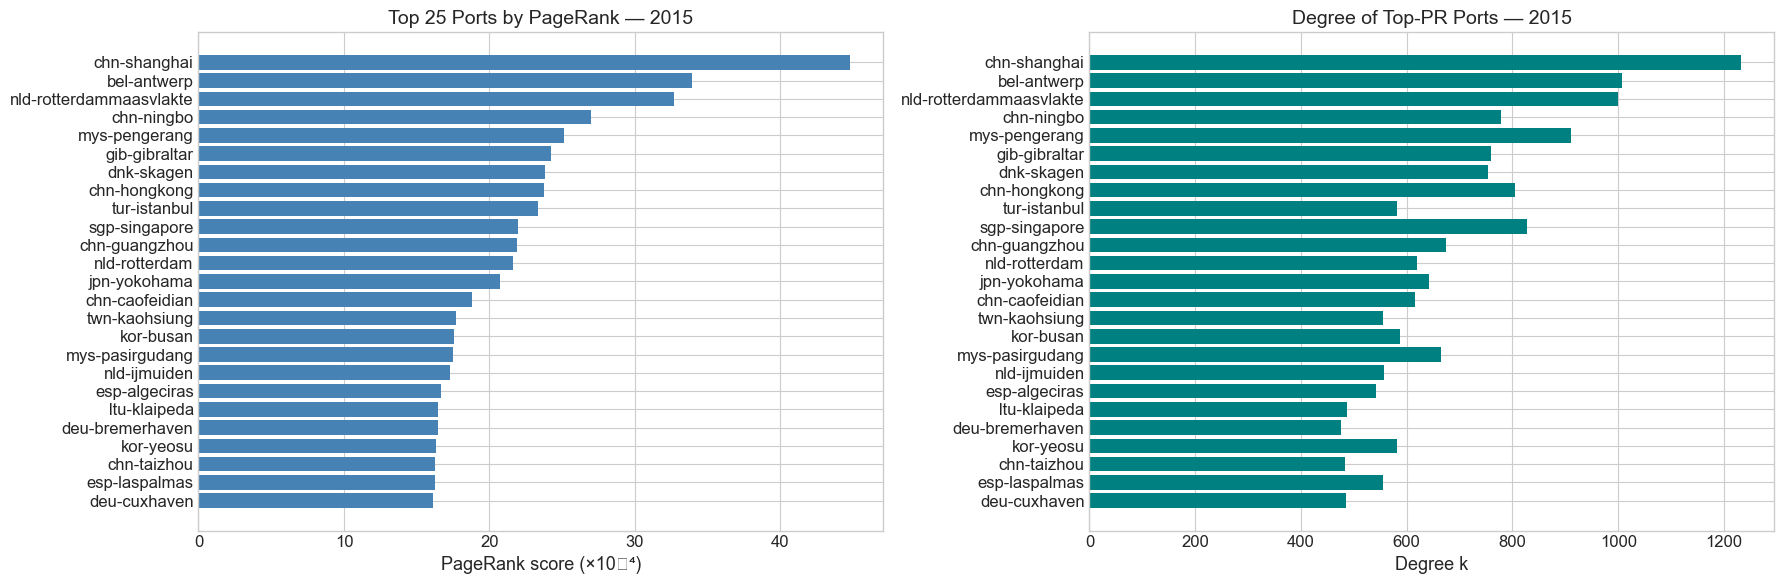


Top 25 ports by PageRank — 2025  (PR values ×10⁻⁴)
 Rank (PR)                    Port  PageRank  Degree k  In-deg  Out-deg  BC Rank
         1            chn-shanghai   38.3928      1171     899      921        2
         2             bel-antwerp   31.2058       901     675      636        3
         3 nld-rotterdammaasvlakte   30.5377       846     626      579        1
         4              chn-ningbo   27.2047       829     664      572        6
         5           chn-guangzhou   22.1418       756     568      543        7
         6        mys-telokramunia   20.9846       974     567      765        4
         7           nld-rotterdam   20.7033       520     442      228        8
         8           gib-gibraltar   20.6596       701     490      528       10
         9              dnk-skagen   20.5382       652     437      483        5
        10            chn-hongkong   20.3660       737     552      516       14
        11               kor-yeosu   16.9040       587   

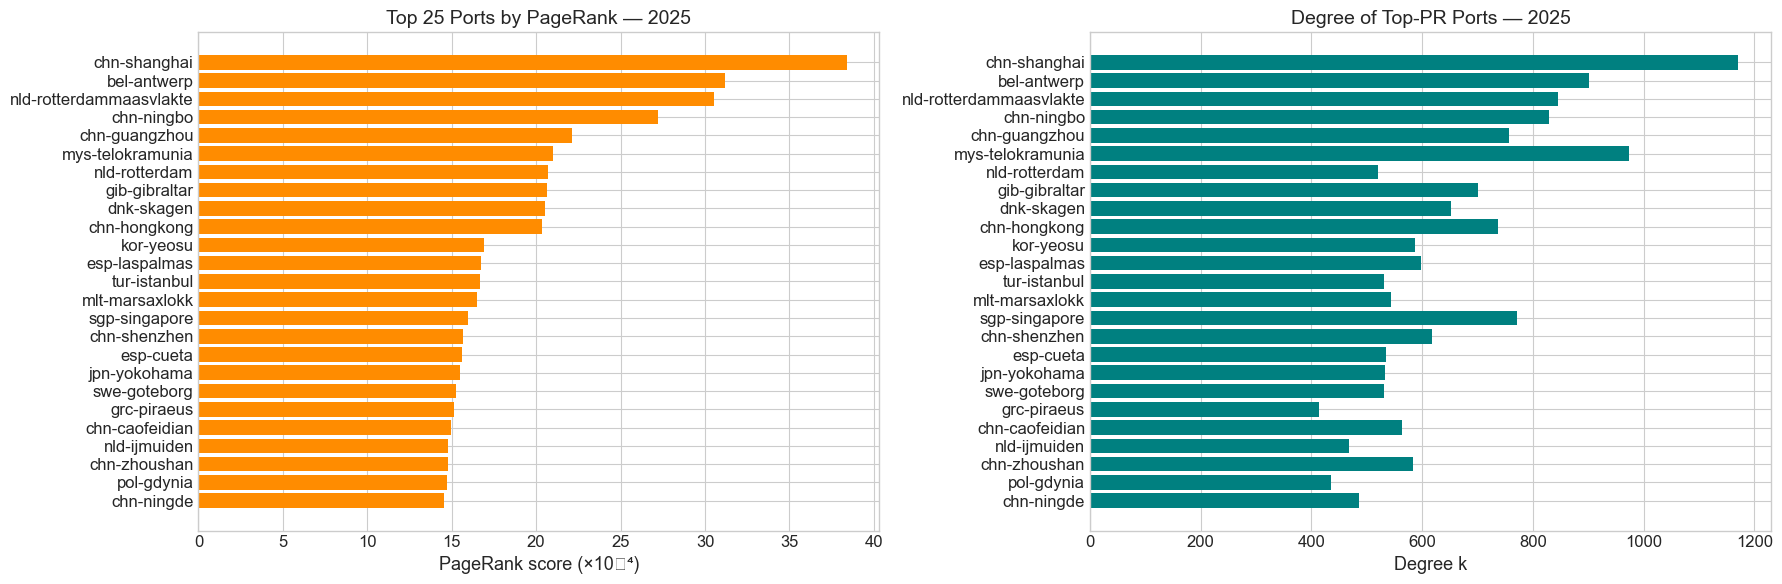


2015  Rank-correlation (Spearman ρ):
  PR  vs Degree : ρ = 0.9098
  PR  vs BC     : ρ = 0.8660
  BC  vs Degree : ρ = 0.8283
  → PR adds little  information beyond degree (ρ=0.91)

2025  Rank-correlation (Spearman ρ):
  PR  vs Degree : ρ = 0.8750
  PR  vs BC     : ρ = 0.8283
  BC  vs Degree : ρ = 0.7777
  → PR adds significant  information beyond degree (ρ=0.88)

PageRank scores saved → ../Figures/01_pagerank.csv


In [38]:
print('Computing PageRank for 2015 and 2025 directed graphs ...')
pr_2015 = nx.pagerank(Gd_2015, alpha=0.85, weight=None, max_iter=1000, tol=1e-6)
pr_2025 = nx.pagerank(Gd_2025, alpha=0.85, weight=None, max_iter=1000, tol=1e-6)

TOP_PR = 25

def pr_table(Gu, Gd, pr_dict, bc_dict, year, top_n=TOP_PR):
    """Build ranked table: PageRank score, degree, and BC rank."""
    u_deg    = dict(Gu.degree())
    in_deg   = dict(Gd.in_degree())
    out_deg  = dict(Gd.out_degree())

    # BC rank lookup
    bc_ranked = sorted(bc_dict, key=bc_dict.get, reverse=True)
    bc_rank   = {p: r+1 for r, p in enumerate(bc_ranked)}

    top = sorted(pr_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
    rows = []
    for rank, (port, pr) in enumerate(top, 1):
        rows.append({
            'Rank (PR)': rank,
            'Port':      port,
            'PageRank':  round(pr * 1e4, 4),   # ×10⁻⁴ for readability
            'Degree k':  u_deg.get(port, 0),
            'In-deg':    in_deg.get(port, 0),
            'Out-deg':   out_deg.get(port, 0),
            'BC Rank':   bc_rank.get(port, '—'),
        })
    df_pr = pd.DataFrame(rows)
    print(f'\nTop {top_n} ports by PageRank — {year}  (PR values ×10⁻⁴)')
    print(df_pr.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    color = 'steelblue' if year == '2015' else 'darkorange'

    axes[0].barh(df_pr['Port'][::-1], df_pr['PageRank'][::-1],
                 color=color, edgecolor='none')
    axes[0].set_xlabel('PageRank score (×10⁻⁴)')
    axes[0].set_title(f'Top {top_n} Ports by PageRank — {year}')

    axes[1].barh(df_pr['Port'][::-1], df_pr['Degree k'][::-1],
                 color='teal', edgecolor='none')
    axes[1].set_xlabel('Degree k')
    axes[1].set_title(f'Degree of Top-PR Ports — {year}')

    plt.tight_layout()
    plt.savefig(FIG_DIR + f'01_pagerank_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return df_pr

df_pr_2015 = pr_table(Gu_2015, Gd_2015, pr_2015, bc_2015, '2015')
df_pr_2025 = pr_table(Gu_2025, Gd_2025, pr_2025, bc_2025, '2025')

# ── Rank-correlation: PR vs Degree vs BC ────────────────────────────────────
from scipy.stats import kendalltau, spearmanr

for year, pr_d, bc_d, Gu in [('2015', pr_2015, bc_2015, Gu_2015),
                               ('2025', pr_2025, bc_2025, Gu_2025)]:
    nodes  = list(Gu.nodes())
    pr_vec = np.array([pr_d[n]  for n in nodes])
    bc_vec = np.array([bc_d[n]  for n in nodes])
    dg_vec = np.array([Gu.degree(n) for n in nodes])

    rho_pr_dg, _ = spearmanr(pr_vec, dg_vec)
    rho_pr_bc, _ = spearmanr(pr_vec, bc_vec)
    rho_bc_dg, _ = spearmanr(bc_vec, dg_vec)

    print(f'\n{year}  Rank-correlation (Spearman ρ):')
    print(f'  PR  vs Degree : ρ = {rho_pr_dg:.4f}')
    print(f'  PR  vs BC     : ρ = {rho_pr_bc:.4f}')
    print(f'  BC  vs Degree : ρ = {rho_bc_dg:.4f}')
    print(f'  → PR adds {"little" if abs(rho_pr_dg) > 0.9 else "significant"} ',
          f'information beyond degree (ρ={rho_pr_dg:.2f})')

# Save combined PageRank scores
pd.DataFrame(
    [(p, pr_2015.get(p, 0), pr_2025.get(p, 0))
     for p in set(pr_2015) | set(pr_2025)],
    columns=['port', 'PR_2015', 'PR_2025']
).sort_values('PR_2015', ascending=False).to_csv(
    '../Figures/01_pagerank.csv', index=False)
print('\nPageRank scores saved → ../Figures/01_pagerank.csv')


## 12. k-core Decomposition

The **k-core** of a graph is the maximal subgraph in which every node has degree ≥ k (Seidman 1983).  
It reveals the **hierarchical shell structure** of the network:

- **Outer shells (low k)**: peripheral ports with few connections
- **Inner shells (high k)**: the dense, mutually-connected *backbone* of the network
- **Maximum k-core**: the innermost core — the smallest set of ports that are all tightly connected to each other

k-core coreness complements the rich-club coefficient: rich-club asks *'are hubs connected to other hubs?'*; k-core asks *'what is the densest clique-like subgraph?'*


Maximum k-core: 2015 = 74,  2025 = 72


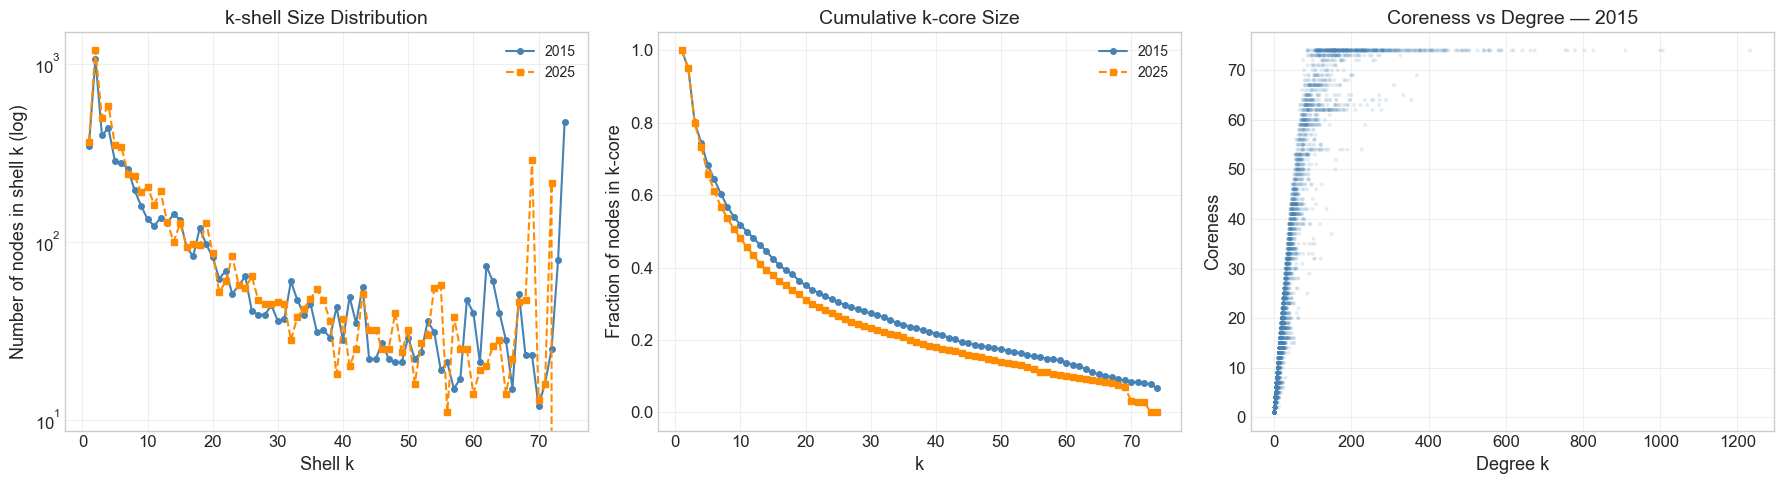


2015 — maximum k-core (k=74): 473 ports
  Innermost core ports: are-fujairah, are-jebelali, are-khorfakkan, arg-buenosaires, arg-sanlorenzo, aus-abbotpoint, aus-adelaide, aus-auntl, aus-aus-429, aus-brisbane, aus-bunbury, aus-dampier, aus-darwin, aus-fremantle, aus-geelong, aus-geraldton, aus-gladstone, aus-haypoint, aus-kwinana, aus-newcastle, aus-porthedland, aus-portkembla, aus-portwalcott, bel-antwerp, bel-zeebrugge, bgd-chittagong, bra-ilhaguaiba, bra-itaguai, bra-itaqui, bra-paranagua

2025 — maximum k-core (k=72): 214 ports
  Innermost core ports: are-fujairah, aus-abbotpoint, aus-auntl, aus-aus-429, aus-brisbane, aus-bunbury, aus-dampier, aus-geelong, aus-geraldton, aus-gladstone, aus-haypoint, aus-kwinana, aus-newcastle, aus-porthedland, aus-portkembla, bgd-chittagong, bra-santos, can-princerupert, can-vancouver, chn-basuo, chn-bayuquan, chn-caofeidian, chn-caojing, chn-changjiangkou, chn-changxingdao, chn-chenjiagang, chn-chn-177, chn-chn-189, chn-chn-2051, chn-chn-2317
2015

In [39]:
# ── Compute coreness for each node ──────────────────────────────────────────
core_2015 = nx.core_number(Gu_2015)
core_2025 = nx.core_number(Gu_2025)

k_max_2015 = max(core_2015.values())
k_max_2025 = max(core_2025.values())
print(f'Maximum k-core: 2015 = {k_max_2015},  2025 = {k_max_2025}')

# Shell size distribution: number of nodes first reaching shell k
from collections import Counter

shell_2015 = Counter(core_2015.values())
shell_2025 = Counter(core_2025.values())

all_k = sorted(set(shell_2015) | set(shell_2025))
sizes_15 = [shell_2015.get(k, 0) for k in all_k]
sizes_25 = [shell_2025.get(k, 0) for k in all_k]

# ── Plot 1: Shell size distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].semilogy(all_k, sizes_15, 'o-', color='steelblue', ms=4, label='2015')
axes[0].semilogy(all_k, sizes_25, 's--', color='darkorange', ms=4, label='2025')
axes[0].set_xlabel('Shell k')
axes[0].set_ylabel('Number of nodes in shell k (log)')
axes[0].set_title('k-shell Size Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Cumulative nodes in k-core ≥ k ──────────────────────────────────
N15 = Gu_2015.number_of_nodes()
N25 = Gu_2025.number_of_nodes()
cum_15 = [sum(shell_2015.get(j, 0) for j in all_k if j >= k) / N15 for k in all_k]
cum_25 = [sum(shell_2025.get(j, 0) for j in all_k if j >= k) / N25 for k in all_k]

axes[1].plot(all_k, cum_15, 'o-', color='steelblue', ms=4, label='2015')
axes[1].plot(all_k, cum_25, 's--', color='darkorange', ms=4, label='2025')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Fraction of nodes in k-core')
axes[1].set_title('Cumulative k-core Size')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Coreness vs Degree scatter (2015) ────────────────────────────────
nodes_15 = list(Gu_2015.nodes())
deg_15   = [Gu_2015.degree(n) for n in nodes_15]
cor_15   = [core_2015[n]      for n in nodes_15]
axes[2].scatter(deg_15, cor_15, alpha=0.15, s=8, color='steelblue', edgecolors='none')
axes[2].set_xlabel('Degree k')
axes[2].set_ylabel('Coreness')
axes[2].set_title('Coreness vs Degree — 2015')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + '01_kcore_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Innermost core ports ─────────────────────────────────────────────────────
for year, core_d, k_max in [('2015', core_2015, k_max_2015),
                              ('2025', core_2025, k_max_2025)]:
    inner_ports = [p for p, c in core_d.items() if c == k_max]
    print(f'\n{year} — maximum k-core (k={k_max}): {len(inner_ports)} ports')
    print('  Innermost core ports:', ', '.join(sorted(inner_ports)[:30]))

# ── Coreness vs BC rank-correlation ─────────────────────────────────────────
from scipy.stats import spearmanr
for year, core_d, bc_d, Gu in [('2015', core_2015, bc_2015, Gu_2015),
                                  ('2025', core_2025, bc_2025, Gu_2025)]:
    nodes  = list(Gu.nodes())
    cor_v  = [core_d[n]  for n in nodes]
    bc_v   = [bc_d[n]    for n in nodes]
    dg_v   = [Gu.degree(n) for n in nodes]
    rho_cd, _ = spearmanr(cor_v, dg_v)
    rho_cb, _ = spearmanr(cor_v, bc_v)
    print(f'{year} Coreness vs Degree: ρ = {rho_cd:.4f} | Coreness vs BC: ρ = {rho_cb:.4f}')

# Save coreness scores
pd.DataFrame(
    [(p, core_2015.get(p, 0), core_2025.get(p, 0))
     for p in set(core_2015) | set(core_2025)],
    columns=['port', 'coreness_2015', 'coreness_2025']
).sort_values('coreness_2015', ascending=False).to_csv(
    '../Figures/01_kcore.csv', index=False)
print('\nCoreness scores saved → ../Figures/01_kcore.csv')


## 13. Summary Table — 2015 vs 2025 vs Kaluza et al. 2007


In [40]:
# Compiling a summary table of key network metrics for both the 2015 and 2025 undirected graphs, and comparing them to the baseline from Kaluza et al. 2010
N_2015 = Gu_2015.number_of_nodes()
N_2025 = Gu_2025.number_of_nodes()
E_2015 = Gu_2015.number_of_edges()
E_2025 = Gu_2025.number_of_edges()
Ed_2015 = Gd_2015.number_of_edges()
Ed_2025 = Gd_2025.number_of_edges()

rows = [
    ('Year',                           '2015',                          '2025',                          '2007 (paper)'),
    ('Data type',                       'Cargo+Container',               'Cargo+Container',               'All cargo ships'),
    ('Nodes N (ports)',                 f'{N_2015:,}',                   f'{N_2025:,}',                   '951'),
    ('Directed edges',                  f'{Ed_2015:,}',                  f'{Ed_2025:,}',                  '—'),
    ('Undirected edges',                f'{E_2015:,}',                   f'{E_2025:,}',                   '—'),
    ('Density (undirected)',            f'{nx.density(Gu_2015):.6f}',    f'{nx.density(Gu_2025):.6f}',    '—'),
    ('Mean undirected degree <k>',      f'{deg_stats["2015"]["mean_undirected"]:.2f}',
                                        f'{deg_stats["2025"]["mean_undirected"]:.2f}', '44.61'),
    ('Max degree',                      f'{deg_stats["2015"]["max_degree"]:,}',
                                        f'{deg_stats["2025"]["max_degree"]:,}',  '—'),
    ('Clustering coefficient C',        f'{res_c_2015["C"]:.4f}',        f'{res_c_2025["C"]:.4f}',        '0.490'),
    ('C(k) decay exponent beta',        f'{res_c_2015["beta"]:.3f}',     f'{res_c_2025["beta"]:.3f}',     '—'),
    ('Avg path length L (sampled GCC)', f'{apl_2015:.4f}',               f'{apl_2025:.4f}',               '2.500'),
    ('Diameter (from sample)',          f'{diam_2015}',                  f'{diam_2025}',                  '—'),
    ('Assortativity r',                 f'{dc_2015["r"]:.4f}',           f'{dc_2025["r"]:.4f}',           '—'),
    ('KNN slope nu',                    f'{dc_2015["nu"]:.4f}',          f'{dc_2025["nu"]:.4f}',          '—'),
    ('Power-law exponent mu (MLE)',      f'{deg_stats["2015"]["mu"]:.3f}',f'{deg_stats["2025"]["mu"]:.3f}','1.710'),
    ('GCC size (% of N)',               f'{gcc_2015.number_of_nodes()/N_2015*100:.1f}%',
                                        f'{gcc_2025.number_of_nodes()/N_2025*100:.1f}%', '—'),
    ('Small-world sigma',               f'{sw_2015["sigma"]:.1f}',       f'{sw_2025["sigma"]:.1f}',       '—'),
    ('Small-world gamma (C/C_rand)',     f'{sw_2015["gamma"]:.1f}',       f'{sw_2025["gamma"]:.1f}',       '—'),
]

# Creating a DataFrame from the list of rows to display the summary of key network metrics in a tabular format, and printing the table to the console with a header and footer for clarity
df_summary = pd.DataFrame(rows, columns=['Metric', '2015', '2025', 'Paper 2007'])

print()
print('=' * 80)
print('  GCSN UNWEIGHTED NETWORK — SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495')
print('=' * 80)
print(df_summary.to_string(index=False))
print('=' * 80)

# Saving the summary table to a CSV file
df_summary.to_csv('../Figures/01_summary_unweighted.csv', index=False)
print('\nSummary saved to ../Figures/01_summary_unweighted.csv')



  GCSN UNWEIGHTED NETWORK — SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495
                         Metric            2015            2025      Paper 2007
                           Year            2015            2025    2007 (paper)
                      Data type Cargo+Container Cargo+Container All cargo ships
                Nodes N (ports)           7,097           7,717             951
                 Directed edges         188,545         182,300               —
               Undirected edges         145,745         139,499               —
           Density (undirected)        0.005788        0.004686               —
     Mean undirected degree <k>           41.07           36.15           44.61
                     Max degree           1,233           1,171               —
       Clustering coefficient C          0.5223          0.4884           0.490
       C(k) decay exponent beta           0.296           0.273          